# 04 — Neural methods & scaling: robustness, and honest nulls

The headline RL edge (notebook 01) and exact Leduc Nash convergence (notebook 02) raise the natural v2 questions: **is the edge a lucky training seed?** and **do *neural* equilibrium methods beat the tabular ones — and does that change at scale?** This notebook reproduces three pre-registered v2 experiments from the committed `results/*.json` (**no retraining**):

1. **Multi-seed robustness** (`PREREGISTRATION.md` §10): retrain the DQN over 20 seeds; is the +256 headline robust, or seed-luck?
2. **Neural NFSP on Leduc** (§11): does a neural average-policy network beat tabular NFSP on the *exact* NashConv metric? (Includes the honest **erratum** that corrected an epsilon-schedule bug.)
3. **Scaling to R=20 "big Leduc"** (§12): where tabular CFR cannot converge, does neural NFSP win at matched budget?

The transferable point is the same as a quant's: a result is only as good as its robustness checks, its exact-vs-lower-bound honesty, and a pre-registration that survives a bug being found *after* the freeze.

In [1]:
import os, sys, json
# Walk up to the repo root (works whether the kernel cwd is notebooks/ or root).
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, "results"))
          and os.path.isdir(os.path.join(ROOT, "src"))) \
        and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from IPython.display import Image, display

def load(name):
    with open(os.path.join(ROOT, "results", name)) as f:
        return json.load(f)

def fig(name):
    display(Image(filename=os.path.join(ROOT, "figures", name)))
print("repo root resolved:", os.path.basename(ROOT))

repo root resolved: poker-simulation


## 1. Is the headline a lucky seed? — multi-seed robustness (§10)

The v1 headline rested on one training seed (`torch_seed=0`). §10 retrains over 20 seeds with the *identical* frozen confirmatory eval, and reports the edge as a **distribution**. We re-derive the across-seed CI from the per-seed edges with the project's own `bootstrap_ci`.

In [2]:
from src.stats import bootstrap_ci
s = load("seed_sweep.json")["summary"]
edges = list(s["per_seed_edge"].values())
ci = bootstrap_ci(edges)   # across-seed 95% CI of the EXPECTED edge of a random init
print(f"trained seeds : {s['n_seeds_trained']}")
print(f"per-seed edge : mean {s['mean_edge']:+.0f}, median {s['median_edge']:+.0f} chips/match")
print(f"across-seed 95% CI of the mean edge : [{ci['lo']:+.0f}, {ci['hi']:+.0f}]  "
      f"(committed [{s['across_seed_ci95']['lo']:+.0f}, {s['across_seed_ci95']['hi']:+.0f}])")
print(f"resolved positive {s['n_resolved_positive']}/{s['n_seeds_trained']}  "
      f"negative {s['n_resolved_negative']}  null {s['n_unresolved']}")
print(f"published seed 0 sits at percentile {s['seed0_percentile']:.2f} "
      f"(below median -> conservative, not cherry-picked)")
print(f"VERDICT: {s['verdict']}")

trained seeds : 20
per-seed edge : mean +351, median +300 chips/match
across-seed 95% CI of the mean edge : [+244, +468]  (committed [+244, +468])
resolved positive 16/20  negative 0  null 4
published seed 0 sits at percentile 0.35 (below median -> conservative, not cherry-picked)
VERDICT: robust


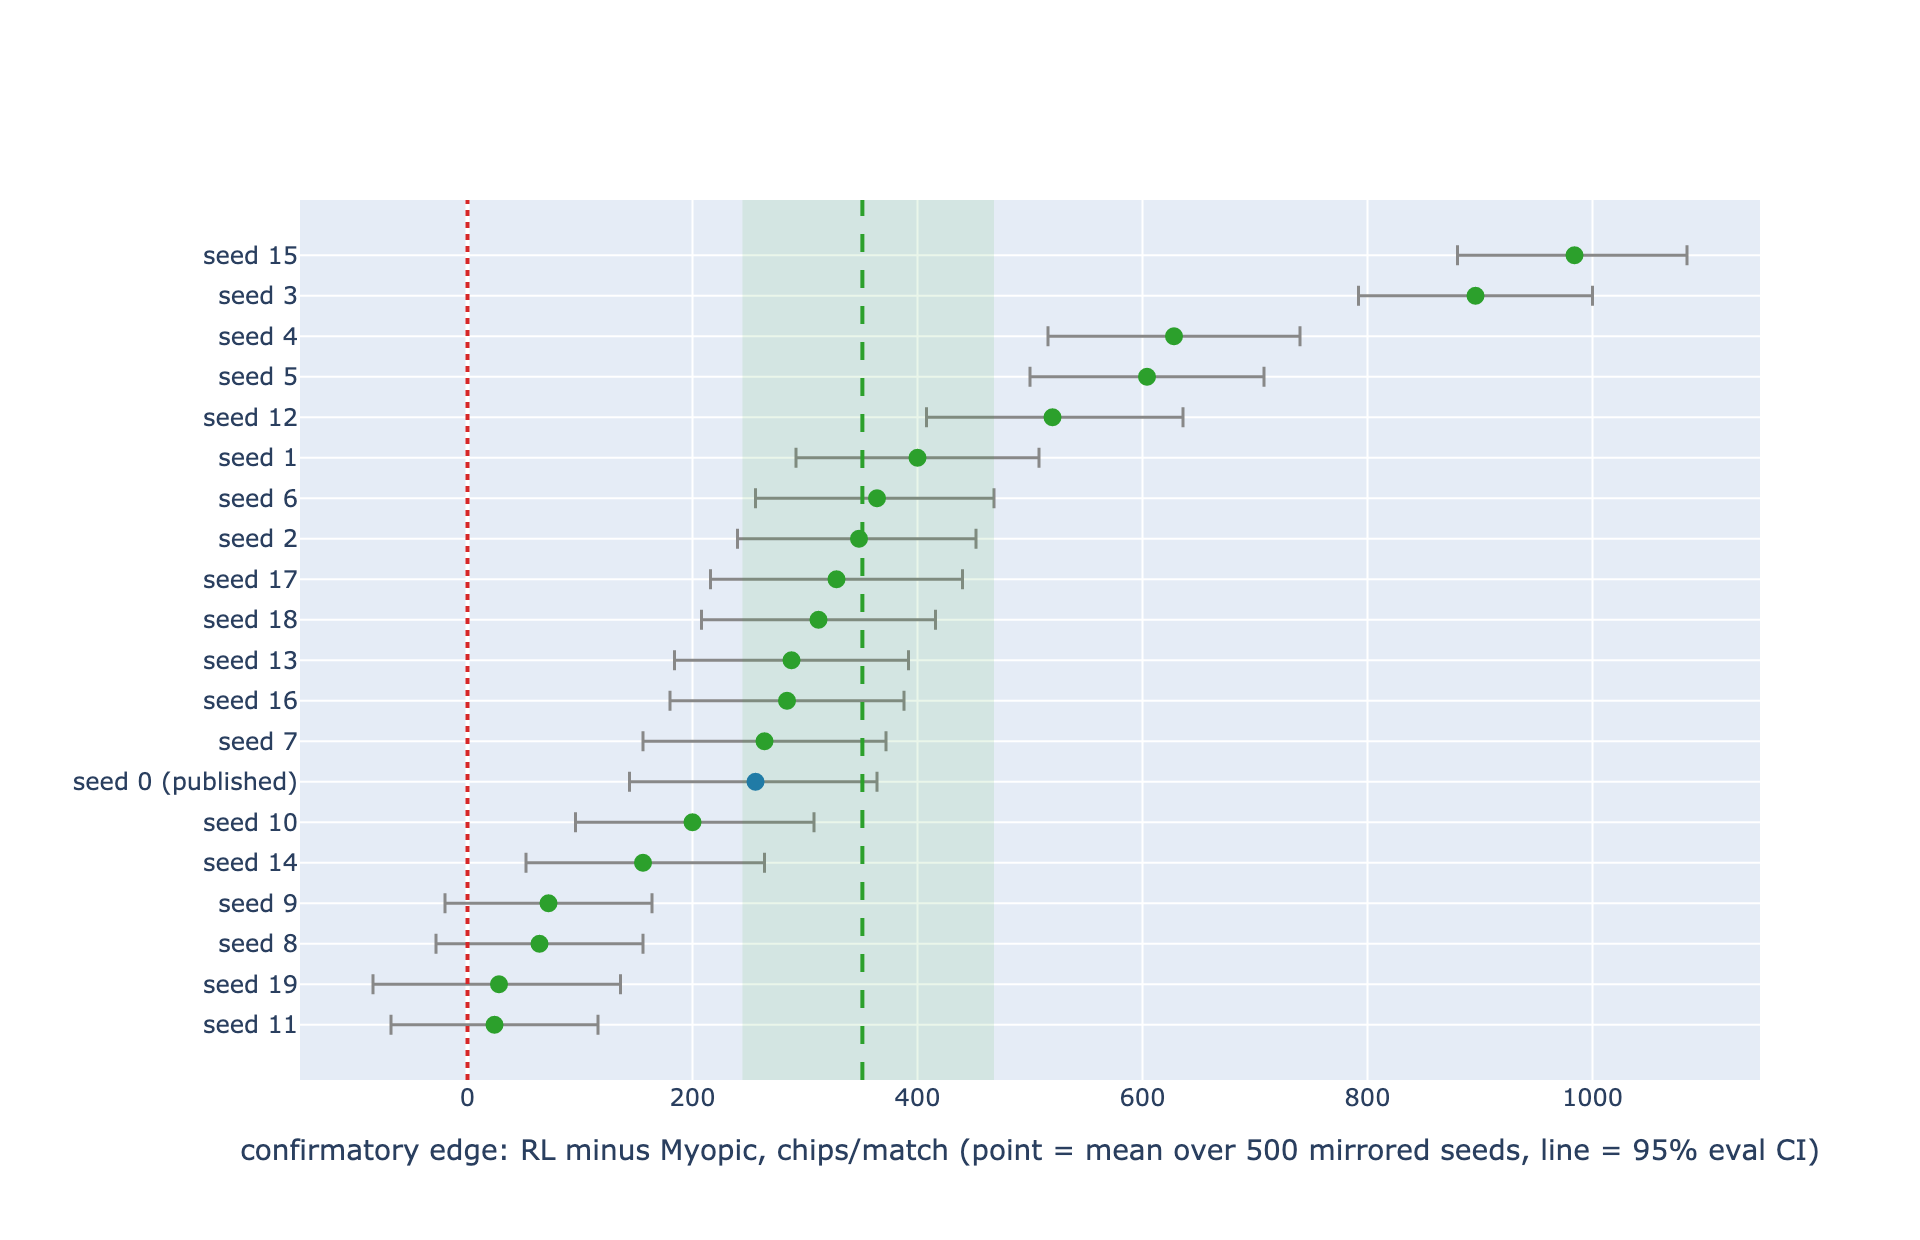

In [3]:
fig("seed_sweep.png")

## 2. Does neural NFSP beat tabular? — exact NashConv on Leduc (§11)

Neural NFSP (Heinrich & Silver 2016) replaces the tabular average-policy table with an MLP, scored by the **identical exact NashConv** metric as the tabular learners. The pre-committed gate (§11.3) is *sample efficiency*: neural must beat tabular at a **majority of the 3 checkpoints**.

**Honest erratum (`PREREGISTRATION.md` §11.4).** The first committed run reset the epsilon anneal once per checkpoint (a sawtooth, not the registered monotone `0.06→0.0`). A code review caught it on correctness grounds; corrected and re-run with identical seeds, the gate flips from a **1/3 null** to a **qualified 2/3 pass**. Both numbers are reported; the fix matches the registered intent. We recompute the gate live from the committed curve.

In [4]:
n = load("neural_nfsp.json")
print(f"{'episodes':>9} {'neural mean':>12} {'tabular':>9} {'neural beats?':>14}")
wins = 0
for h in n["head_to_head"]:
    wins += bool(h["neural_beats_tabular"])
    print(f"{h['episodes']:>9} {h['neural_mean']:>12.2f} {h['tabular']:>9.2f} "
          f"{('yes' if h['neural_beats_tabular'] else 'no'):>14}")
gate = (len(n["head_to_head"]) == 3 and wins >= 2)
uni = n["uniform_exploitability"]; floor = n["cfr_avg_final"]
print(f"\npre-committed gate (majority of 3): {wins}/3 -> "
      f"{'HOLDS (a qualified sample-efficiency pass)' if gate else 'FAILS (an honest null)'}")
print(f"converges {uni:.2f} (uniform) -> {n['curve'][-1]['mean_exploitability']:.2f} at 200k; "
      f"both far above the CFR Nash floor {floor:.3f}")
print("note: neural wins at the SMALLER budgets (50k, 100k); tabular wins asymptotically (200k)")
print("      -- exactly the a-priori §11.3 prediction (sample efficiency, not asymptotic).")

 episodes  neural mean   tabular  neural beats?
    50000         1.87      2.40            yes
   100000         1.70      1.80            yes
   200000         1.59      1.34             no

pre-committed gate (majority of 3): 2/3 -> HOLDS (a qualified sample-efficiency pass)
converges 4.75 (uniform) -> 1.59 at 200k; both far above the CFR Nash floor 0.009
note: neural wins at the SMALLER budgets (50k, 100k); tabular wins asymptotically (200k)
      -- exactly the a-priori §11.3 prediction (sample efficiency, not asymptotic).


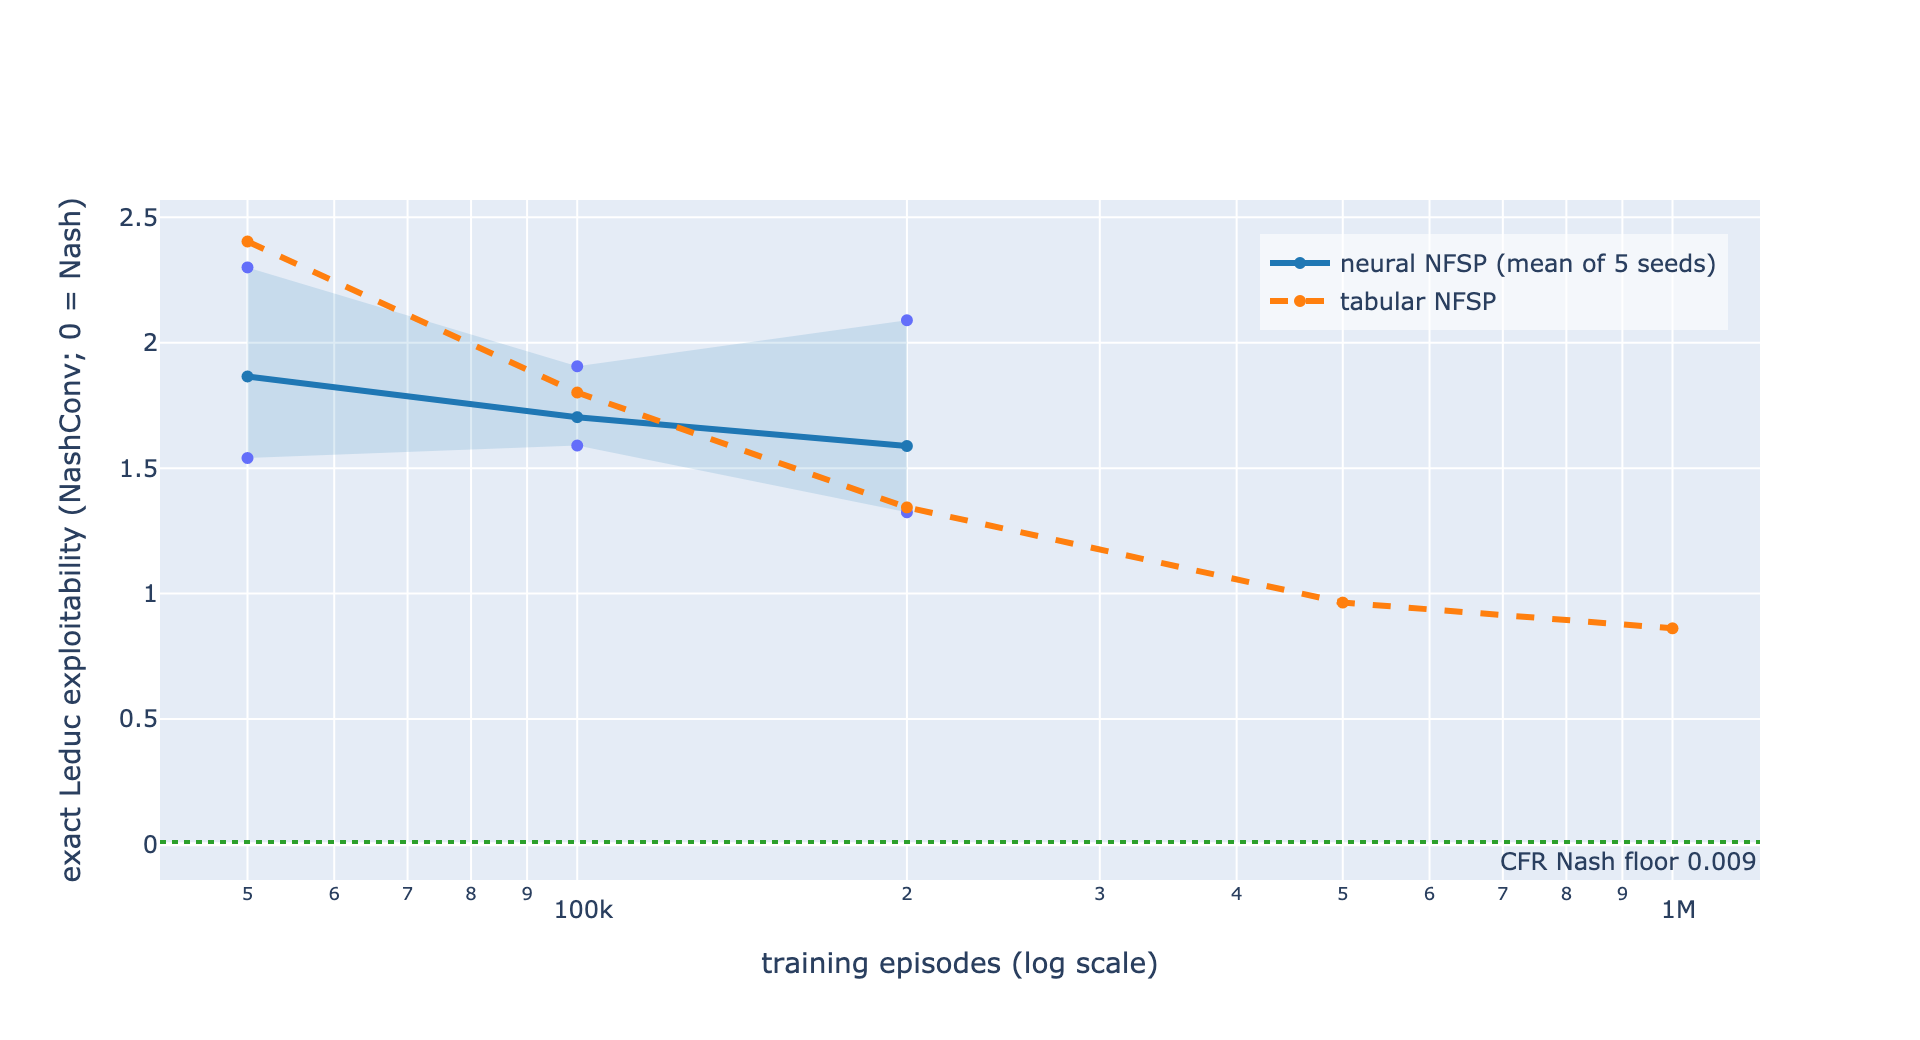

In [5]:
fig("neural_nfsp.png")

## 3. Scaling where tabular CFR cannot converge — R=20 "big Leduc" (§12)

To test the neural method's *raison d'être* — games too large to tabulate — §12 scales Leduc to R=20 ranks, where a full CFR iteration is so costly that convergence (~10⁴ iterations) is **infeasible (~35 h)**. At a matched compute budget both policies are scored by exact NashConv (still a one-time best response, feasible even though convergence is not), cross-checked by the validated **LBR lower bound** (which we re-verify ≤ exact for every policy).

In [6]:
sc = load("scale_experiment.json")
hh = sc["head_to_head"]
print(f"R={sc['ranks']}: {sc['info_sets']} info-sets, {sc['deals_per_cfr_iter']} deals/CFR-iter")
print(f"  tabular CFR convergence estimate ~ {sc['cfr_converge_hours_est']:.0f} h -> infeasible")
print(f"matched-budget exact NashConv (lower is better):")
print(f"  tabular CFR (30 iters)      = {hh['tabular_exact']:.3f}")
print(f"  neural NFSP (200k ep, 3 sd) = {hh['neural_exact_mean']:.3f}")
print(f"  -> {'NEURAL' if hh['neural_beats_tabular_at_matched_budget'] else 'TABULAR'} "
      f"wins decisively -> honest null at scale")
# LBR is a LOWER bound; re-verify LBR <= exact for every scored policy (mirrors the schema test).
tol = 1e-6
pairs = [("uniform", sc["uniform"]), ("tabular_cfr", sc["tabular_cfr"])]
pairs += [(f"neural[{p['seed']}]", p) for p in sc["neural_nfsp"]["per_seed"]]
ok = all(p["lbr"] <= p["exact"] + tol for _, p in pairs)
print(f"LBR <= exact for every policy (uniform / CFR / each neural seed): {ok}")
print("  (LBR is a LOWER bound only -- it can demonstrate exploitation, never CERTIFY low exploitability)")

R=20: 12120 info-sets, 59280 deals/CFR-iter
  tabular CFR convergence estimate ~ 35 h -> infeasible
matched-budget exact NashConv (lower is better):
  tabular CFR (30 iters)      = 0.253
  neural NFSP (200k ep, 3 sd) = 1.004
  -> TABULAR wins decisively -> honest null at scale
LBR <= exact for every policy (uniform / CFR / each neural seed): True
  (LBR is a LOWER bound only -- it can demonstrate exploitation, never CERTIFY low exploitability)


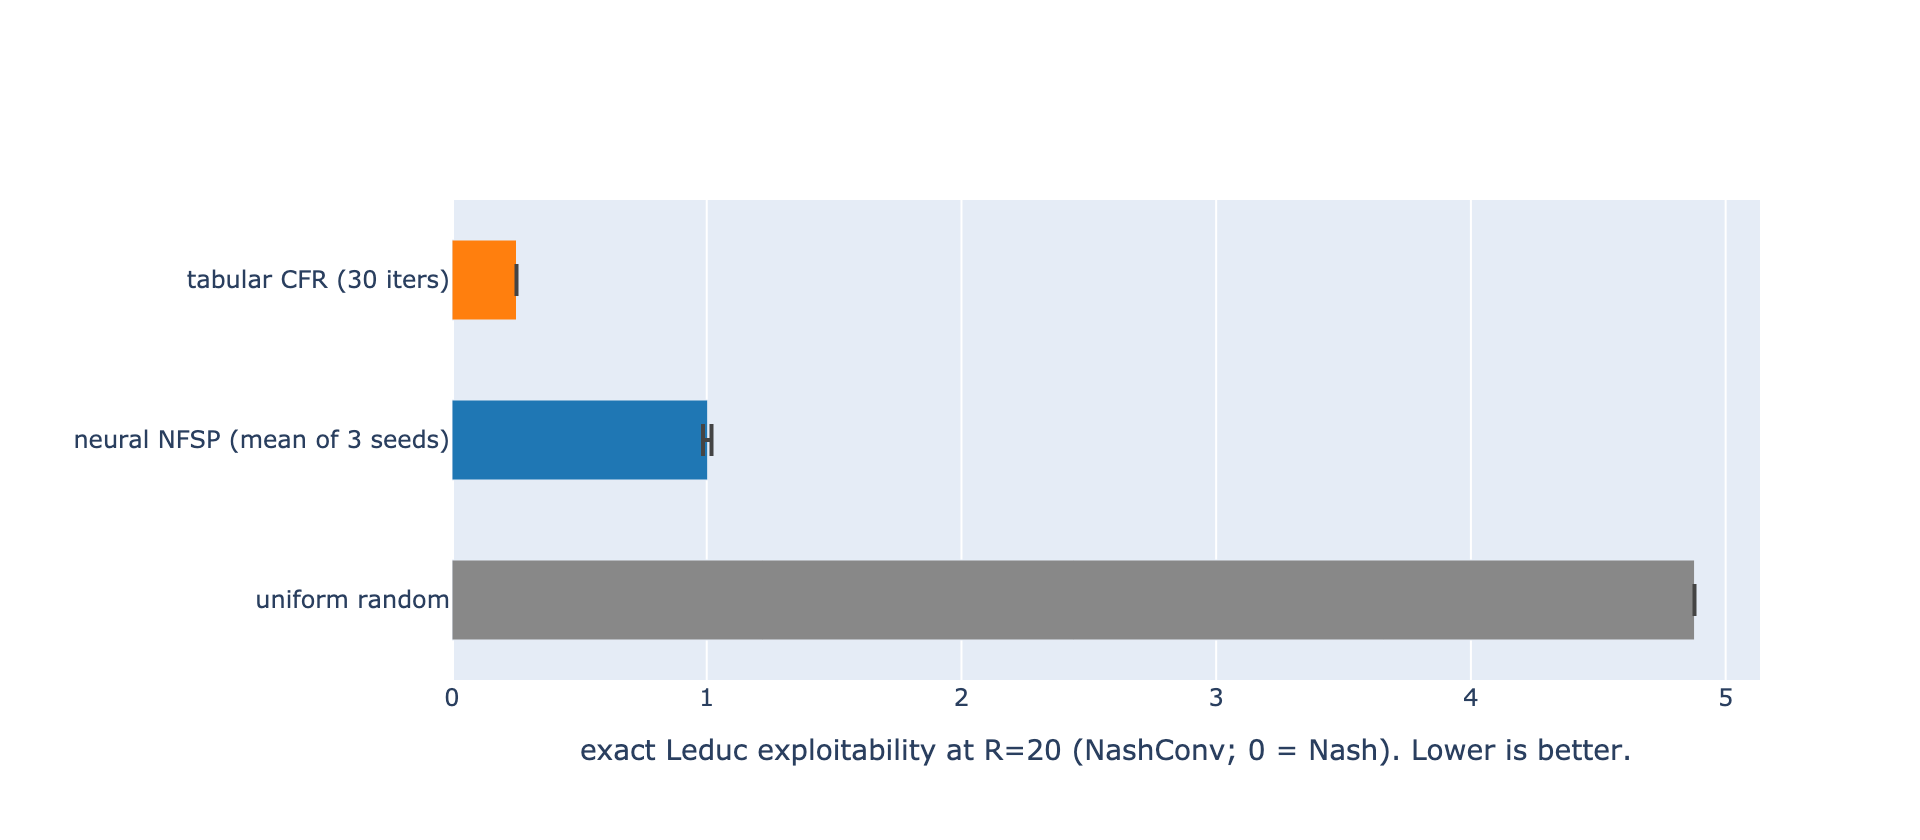

In [7]:
fig("scale.png")

### Honest takeaway

Across the three v2 experiments: the headline RL edge is **robust** to the training seed (§10: 16/20 seeds resolve positive, 0 negative, seed 0 conservative at the 35th percentile); neural NFSP is at best **weakly more sample-efficient** than tabular on tiny Leduc (§11: a qualified 2/3 pass at the smaller budgets, but tabular wins asymptotically — and the result only emerged after a transparently-reported bug-fix); and at R=20, where tabular CFR cannot converge, **truncated tabular CFR still beats neural NFSP decisively** at matched budget (§12 — an honest null), with LBR validated as a lower bound at scale.

So neural equilibrium methods show **no edge at reaching low exploitability at any scale this work can exactly evaluate** — their real advantage lives at HUNL scale, beyond exact measurement (where only a lower bound applies). The transferable artifact, again, is the **measurement discipline**: multi-seed robustness over single-seed luck, the *exact* metric where tractable and a *labelled lower bound* where not, pre-registration with a git-provable freeze→result gap, and an erratum that corrected a frozen result the moment a bug was found — in the open. See `PREREGISTRATION.md` §10–§12 and `THESIS.md`.